# Manual DISKNET Analysis
**Data source:** Dann, D., Maedche, A., Teubner, T., Mueller, B., Meske, C., & Funk, B. (2019). DISKNET - A Platform for the Systematic Accumulation of Knowledge in IS Research. *ICIS 2019 Proceedings*.

In [1]:
import sys
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent 
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.parsimony_purity_trade_off import return_best_cluster_solution
from DISKNET_analysis.analysis_helpers import analyze_clusters, plot_global_model

# Load data
construct_df = pd.read_csv(PROJECT_ROOT/ 'DISKNET_ANALYSIS/data/construct_info.csv')
similarity_df = pd.read_csv(PROJECT_ROOT/ 'DISKNET_ANALYSIS/data/similarities.csv', index_col=0)
grid_search_results_df = pd.read_csv(PROJECT_ROOT/ 'DISKNET_ANALYSIS/data/cluster_grid_search_results.csv')

## 1 Analyze Clusters
Enter an $\alpha$ as well as display settings below and execute the cell to analyze the corresponding cluster solution.

In [2]:
### Enter analysis settings here ###

# Alpha determines the selected cluster solution
alpha = 0.8  # Enter a value in [0,1]. Higer values prioritize purity over parsimony and vice versa. 

# Display settings
top_k = 10  # Top k clusters to display
search_construct = None  # Enter a string value to search for a construct. If specified, only the cluster containing the construct is displayed.

####################################

_, cluster_df = return_best_cluster_solution(
    alpha=alpha, 
    purity_loss_type='intra_cluster_dissimilarity', 
    results_df=grid_search_results_df, 
    similarity_df=similarity_df, 
    seed=1
)

analyze_clusters(
    cluster_df=cluster_df, 
    construct_df=construct_df, 
    k=top_k, 
    search_construct=search_construct
)


Total number of clusters: 3268

Total number of constructs: 5261

Cluster 140 (size: 72):
  - Perceived Usefulness [occurrences: 72]

Cluster 631 (size: 59):
  - Gender [occurrences: 59]

Cluster 169 (size: 53):
  - Age [occurrences: 53]

Cluster 199 (size: 53):
  - Perceived ease of use [occurrences: 53]

Cluster 1376 (size: 42):
  - Behavioral Intention [occurrences: 34]
  - Behavioral Intentions [occurrences: 4]
  - Behavioral Intent [occurrences: 2]
  - Behavioral Intent Information [occurrences: 1]
  - Behavioural Intention [occurrences: 1]

Cluster 64 (size: 38):
  - Attitude [occurrences: 26]
  - Attitude Confidence [occurrences: 2]
  - Attitudes [occurrences: 2]
  - Attitude at time 1 [occurrences: 1]
  - Attitude Toward Using [occurrences: 1]
  - Attitude Toward Using Technology [occurrences: 1]
  - Attitude towards technology usage [occurrences: 1]
  - Attitude towards the technology [occurrences: 1]
  - Attitude Towards Use [occurrences: 1]
  - Attitude Valence [occurrences

## 2 Visualize the Global Model
The code below allows displaying the global model for a cluster solution. Cluster names and the signs of inter-cluster relationships are determined via majority voting. Note that plotting global models requires providing a CSV containing the construct relations. 

In [3]:
# Load relation data
relation_df = pd.read_csv(PROJECT_ROOT/ 'DISKNET_ANALYSIS/data/relation_info.csv')

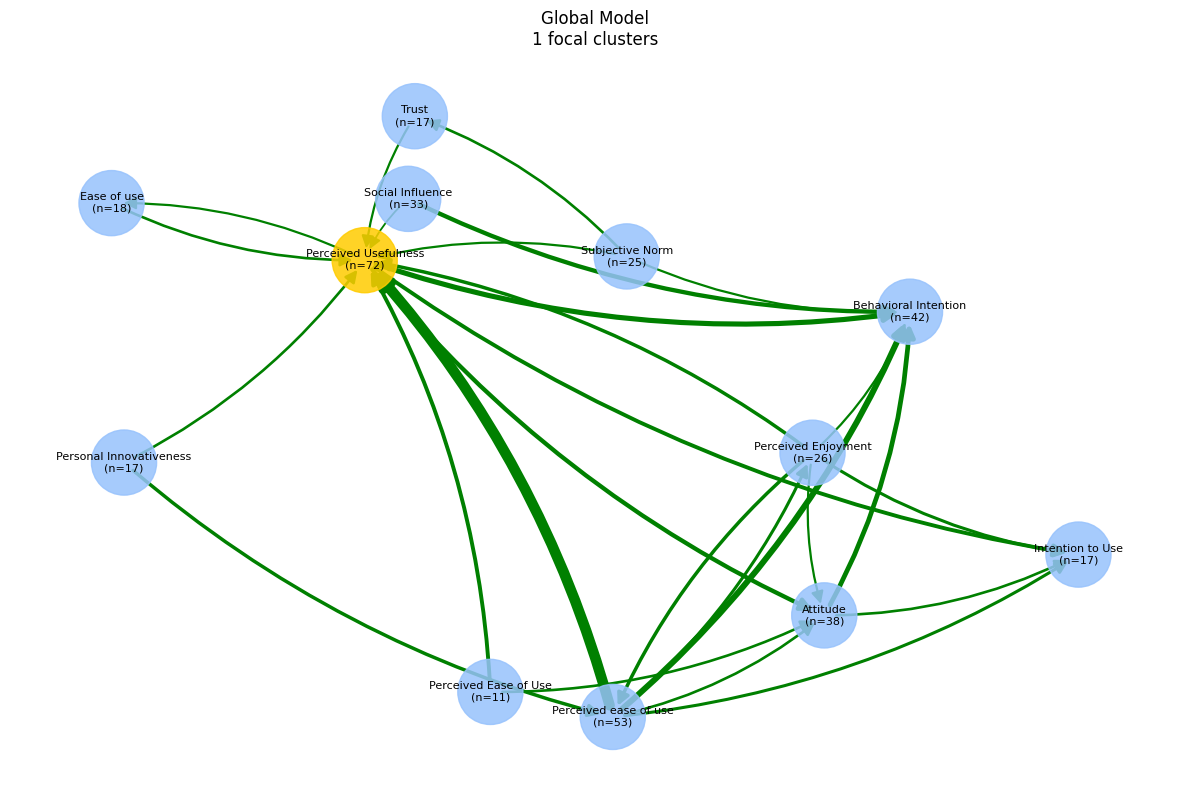

In [4]:
### Enter display settings here ###

min_relation_votes = 2  # Minimum number of relations from one cluster to another
min_cluster_size = 10  # Minimum number of constructs in a cluster
search_construct = 'Perceived usefulness'  # Only the clusters containing the specified construct (focal clusters) and their neighbors are displayed. Set None for not applying this filter.
neighbor_deg = 1  # Maximal degree of neighbors of focal clusters
interactive = False  # If True, an interactive plot is produced and opened in the Browser (recommended for larger graphs). If False, a static plot is produced.
figsize = (12, 8)  # Size of the static plot
html_file = str(PROJECT_ROOT/ 'DISKNET_analysis/temp/interactive_vis.html')  # Path to store the .html file of the interactive plot

####################################

plot_global_model(
    cluster_df=cluster_df,
    construct_df=construct_df,
    relation_df=relation_df,
    min_relation_votes=min_relation_votes,
    min_cluster_size=min_cluster_size,
    search_construct=search_construct,
    neighbor_deg=neighbor_deg,
    interactive=interactive,
    figsize=figsize,
    html_file=html_file
)